# Reinforcement Learning: Holding a Heated Plate at a Target Temperature

A square plate of side 0.1 m has its edges held at 20 C and a heater in the middle ninth of its area. The heater is a source term $S$, in C/s, in the temperature equation:

$$\frac{\partial T}{\partial t} = D\,\nabla^2 T + S$$

At full power, $S = 4$ C/s, the middle of the plate ends near 31 C. The task is to hold it at 25 C instead, choosing $S$ between 0 and 4 C/s every 2 s from the temperature at the middle. Without control the problem has an exact solution as a Fourier series (Carslaw and Jaeger, *Conduction of Heat in Solids*, 2nd ed., Oxford, 1959).

The policy runs inside OpenFOAM: the solver evaluates the network and applies its action through the `uqtopusSource` term.

In [1]:
%%capture
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import onnxruntime as ort

import uqtopus as uqt
import uqtopus.rl as rl
from uqtopus.rl.algos import PPO

root = Path("experiments/heatedPlate")

## 1. The problem without control

With no controller rendered, the template fixes the heater at `S`.

In [3]:
exp_config = {
    "input_path": "templates/heatedPlate",
    "output_path": str(root / "uncontrolled"),
    "solver": "Allrun",
}
uqt.run_simulation(params={"constant__fvModels__S": 4.0, "system__controlDict__controller": ""}, exp_config=exp_config)

uncontrolled = uqt.parse_openfoam_case(case_dir=exp_config["output_path"], variables=["T"])
uncontrolled

<xarray.Dataset> Size: 445kB
Dimensions:  (time: 11, cell: 3969)
Coordinates:
  * time     (time) float64 88B 0.0 3.0 6.0 9.0 12.0 ... 21.0 24.0 27.0 30.0
    x        (cell) float64 32kB 0.0007937 0.002381 0.003968 ... 0.09762 0.09921
    y        (cell) float64 32kB 0.0007937 0.0007937 ... 0.09921 0.09921
    z        (cell) float64 32kB 0.0008333 0.0008333 ... 0.0008333 0.0008333
Dimensions without coordinates: cell
Data variables:
    T        (time, cell) float64 349kB 20.0 20.0 20.0 20.0 ... 20.02 20.01 20.0

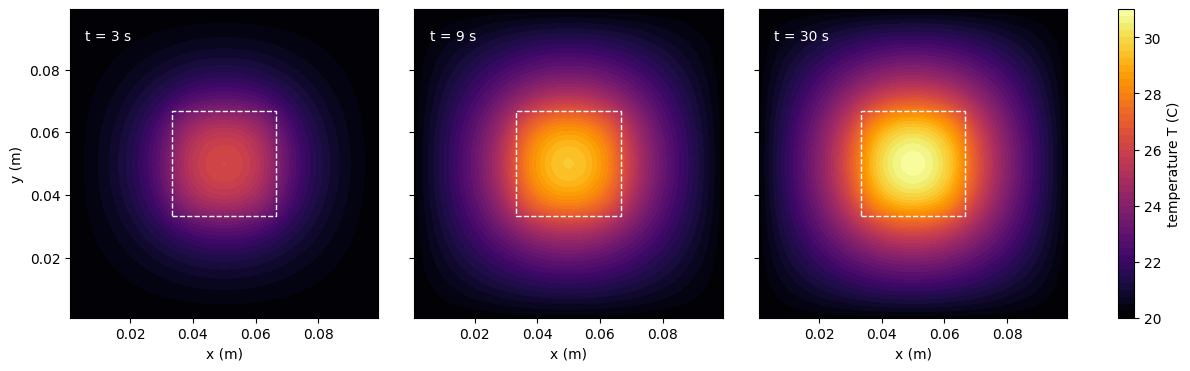

In [4]:
x, y = uncontrolled.x.values, uncontrolled.y.values
levels = np.linspace(20, 31, 45)

fig, axs = plt.subplots(1, 3, figsize=(12, 3.6), sharey=True, constrained_layout=True)
for ax, t in zip(axs, [3, 9, 30]):
    image = ax.tricontourf(x, y, uncontrolled["T"].sel(time=t), levels=levels, cmap="inferno")
    ax.add_patch(plt.Rectangle((0.1 / 3, 0.1 / 3), 0.1 / 3, 0.1 / 3, fill=False, color="white", linestyle="--"))
    ax.text(0.05, 0.9, f"t = {t} s", transform=ax.transAxes, color="white")
    ax.set_xlabel("x (m)")
    ax.set_aspect("equal")
axs[0].set_ylabel("y (m)")
fig.colorbar(image, ax=axs, label="temperature T (C)", ticks=[20, 22, 24, 26, 28, 30])
plt.show()

## 2. Policy spec

What the policy sees, what it drives and how often. The target `heater` is the entry of `constant/fvModels` that takes the action.

In [5]:
spec = rl.PolicySpec(
    observation=rl.ObservationSpec(
        sources=(rl.ProbeSource(field_name="T", positions=[(0.05, 0.05, 0.0008)], name="middle"),)
    ),
    action=rl.ActionSpec(name="S", targets="heater", low=0.0, high=4.0),
    control_interval=2.0,
)
spec

PolicySpec(obs_dim=1, act_dim=1, dist='gaussian', dt=2.0, hash=bafe4e35c011607b)

## 3. The ONNX policy

The network leaves Python as an ONNX file with the spec stamped in its metadata. The graph takes the observation and one standard normal draw, and returns the action; a zero draw returns the mean.

In [6]:
untrained = rl.export_random_policy(spec, root / "policy_untrained.onnx", seed=0)
rl.read_metadata(untrained.path)

{'uqtopus.spec_hash': 'bafe4e35c011607b',
 'uqtopus.spec': '{"action": {"distribution": "gaussian", "high": [4.0], "low": [0.0], "n_components": 1, "name": "S", "ramp_fraction": 0.0, "targets": ["heater"]}, "control_interval": 2.0, "end_time": null, "observation": {"sources": [{"components": null, "field_name": "T", "interpolation": "cellPoint", "kind": "probe", "name": "middle", "positions": [[0.05, 0.05, 0.0008]]}]}, "start_time": 0.0}',
 'uqtopus.obs_dim': '1',
 'uqtopus.act_dim': '1',
 'uqtopus.distribution': 'gaussian',
 'uqtopus.action_low': '0.0',
 'uqtopus.action_high': '4.0',
 'uqtopus.control_interval': '2.0',
 'uqtopus.start_time': '0.0',
 'uqtopus.ramp_fraction': '0.0',
 'uqtopus.action_targets': 'heater:0',
 'uqtopus.backend': 'torch',
 'uqtopus.opset': '17',
 'uqtopus.iteration': '',
 'uqtopus.normalization': '{"mean": [0.0], "std": [1.0]}'}

In [7]:
session = ort.InferenceSession(str(untrained.path), providers=["CPUExecutionProvider"])
session.run(None, {"observation": np.array([[20.0]], dtype=np.float32), "noise": np.zeros((1, 1), dtype=np.float32)})

[array([[-0.25785542]], dtype=float32)]

## 4. The contract in the case

The rendered spec is the `uqtopusPolicy` entry of `system/controlDict`. Rendered into `constant/fvModels` as well, it turns the heater into a `uqtopusSource`.

In [8]:
print(rl.render_controller(spec, untrained.path.resolve()))

uqtopusPolicy
{
    type            uqtopusPolicy;
    policy          "/home/gbm/projects/UQTOPUS/examples/experiments/heatedPlate/policy_untrained.onnx";
    specHash        bafe4e35c011607b;
    controlInterval 2;
    startTime       0;
    observation
    {
        dim             1;
        sources
        (
            {
                kind            probe;
                fieldName       T;
                positions
                (
                    (0.05 0.05 0.0008)
                );
                name            middle;
                interpolation   cellPoint;
            }
        );
    }
    action
    {
        name            S;
        nComponents     1;
        distribution    gaussian;
        rampFraction    0;
        low             (0);
        high            (4);
        targets
        (
            {
                name            heater;
                component       0;
            }
        );
    }
}


## 5. The untrained policy in OpenFOAM

The runner renders the contract, runs the case and reads the trajectory back as an `xr.Dataset`. The `probes` function object writes the temperature at the middle as column `0`; averaged over each control step, it gives the reward.

In [9]:
runner = rl.ClosedLoopRunner(
    uqt.OpenFOAMSimulator(template_path="templates/heatedPlate", solver_script="Allrun",
                          output_path=root / "runs", qoi_variables=["T"]),
    spec,
    reward_fn=lambda ds: -np.abs(ds["0"] - 25.0),
    controller_keys=["system__controlDict__controller", "constant__fvModels__controller"],
    function_objects=["probes"],
)

before = runner.collect(untrained).episodes[0]
before_T = rl.read_function_object(before.attrs["case_dir"], "probes")["0"]
before

<xarray.Dataset> Size: 644B
Dimensions:        (time: 15, obs_component: 1, act_component: 1)
Coordinates:
  * time           (time) float64 120B 2.0 4.0 6.0 8.0 ... 24.0 26.0 28.0 30.0
  * obs_component  (obs_component) <U10 40B 'middle.T.0'
  * act_component  (act_component) <U1 4B 'S'
Data variables:
    observation    (time, obs_component) float64 120B 20.0 20.0 ... 21.9 21.05
    action         (time, act_component) float64 120B -0.2594 1.729 ... -0.3942
    0              (time) float64 120B 20.0 21.37 21.39 ... 21.49 21.36 20.8
    reward         (time) float64 120B -4.999 -3.634 -3.609 ... -3.644 -4.201
Attributes:
    spec_hash:  bafe4e35c011607b
    seed:       0
    source:     experiments/heatedPlate/runs/iter0000_ep00/postProcessing/uqt...
    n_steps:    15
    case_dir:   experiments/heatedPlate/runs/iter0000_ep00
    diverged:   False

## 6. Training

Every iteration exports the current policy, runs four episodes with it at once, and updates the network on what they wrote.

In [10]:
model = PPO("MlpPolicy", runner, n_episodes=4, n_jobs=4, export_dir=root / "policies",
            learning_rate=3e-3, batch_size=30, n_epochs=20, gamma=0.9,
            policy_kwargs={"net_arch": [32, 32]}, seed=0)
model.learn(total_timesteps=30 * 4 * 15)
trained = model.export_current_policy(root / "policy_trained.onnx")

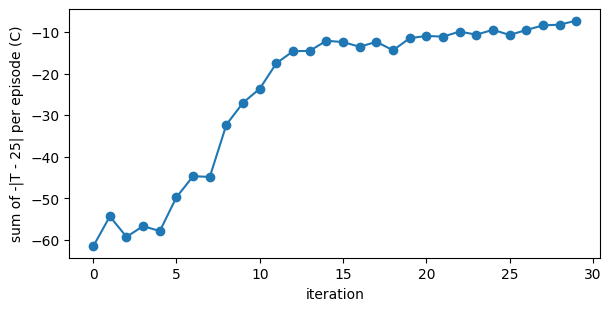

In [11]:
fig, ax = plt.subplots(figsize=(6, 3), constrained_layout=True)
ax.plot(model.returns_history, "o-")
ax.set_xlabel("iteration")
ax.set_ylabel("sum of -|T - 25| per episode (C)")
plt.show()

## 7. Without control, untrained and trained

The trained policy runs deterministic: the solver feeds it a zero draw, so it applies the mean of its distribution.

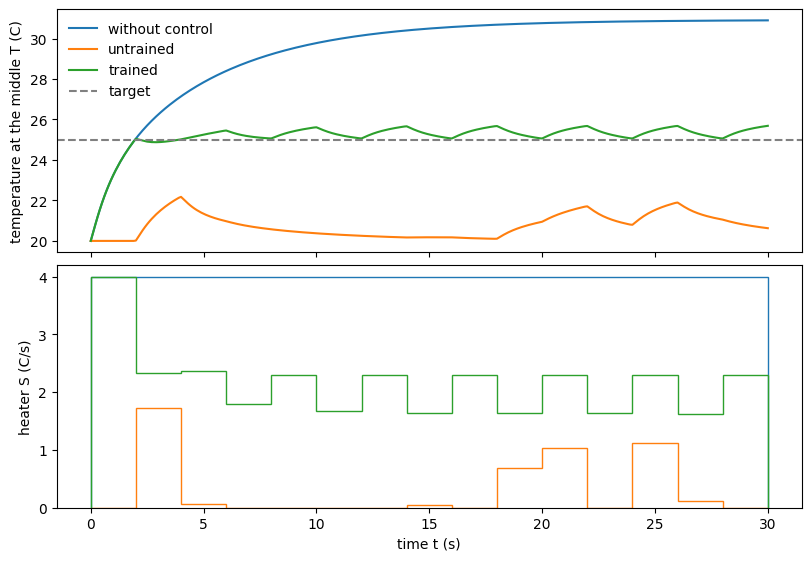

In [12]:
block = rl.render_controller(spec, trained.path.resolve(), extra={"deterministic": True})
trained_config = {"input_path": "templates/heatedPlate", "output_path": str(root / "trained"), "solver": "Allrun"}
uqt.run_simulation(params={"system__controlDict__controller": block, "constant__fvModels__controller": block},
                   exp_config=trained_config)

after = rl.read_trajectory(trained_config["output_path"], spec)
after_T = rl.read_function_object(trained_config["output_path"], "probes")["0"]
uncontrolled_T = rl.read_function_object(exp_config["output_path"], "probes")["0"]
edges = np.r_[0.0, after.time.values]

fig, axs = plt.subplots(2, 1, figsize=(8, 5.5), sharex=True, constrained_layout=True)
for label, T, S in [
    ("without control", uncontrolled_T, np.full(after.sizes["time"], 4.0)),
    ("untrained", before_T, np.clip(before["action"].values[:, 0], 0, 4)),
    ("trained", after_T, np.clip(after["action"].values[:, 0], 0, 4)),
]:
    axs[0].plot(T.time, T, label=label)
    axs[1].stairs(S, edges)
axs[0].axhline(25, color="gray", linestyle="--", label="target")
axs[0].set_ylabel("temperature at the middle T (C)")
axs[1].set_ylabel("heater S (C/s)")
axs[1].set_xlabel("time t (s)")
axs[0].legend(frameon=False)
plt.show()